<a href="https://colab.research.google.com/github/Isu12/ml-kidney-disease-prediction/blob/feature%2Fknn-model-implementation/notebooks/knn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.95

Confusion Matrix:
 [[28  0]
 [ 4 48]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93        28
           1       1.00      0.92      0.96        52

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80



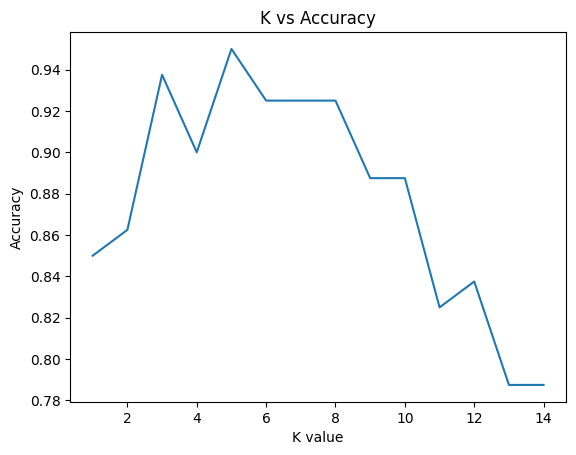

Cross-validation accuracy: 0.9120535714285714


In [5]:
# ==============================
# STEP 1 — IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt


# ==============================
# STEP 2 — LOAD DATA
# ==============================
data_path = Path('data/kidney_disease.csv')
if not data_path.exists():
    data_path = Path('../data/kidney_disease.csv')
df = pd.read_csv(data_path)


# ==============================
# STEP 3 — CLEAN DATA (VERY IMPORTANT)
# ==============================

# Remove spaces/tabs from all text
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Normalize target values
df['classification'] = df['classification'].str.lower()

# Convert target to numeric
df['classification'] = df['classification'].replace({
    'ckd': 1,
    'notckd': 0
})

df['classification'] = pd.to_numeric(df['classification'], errors='coerce')

# Drop bad rows
df = df.dropna(subset=['classification'])


# ==============================
# STEP 4 — SPLIT FEATURES & TARGET
# ==============================
y = df['classification'].astype(int)

X = df.drop('classification', axis=1)

# Remove useless column
if 'id' in X.columns:
    X = X.drop('id', axis=1)


# ==============================
# STEP 5 — ENCODE FEATURES
# ==============================
X = pd.get_dummies(X)


# ==============================
# STEP 6 — TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# STEP 7 — PIPELINE (NO NaN + SCALING + MODEL)
# ==============================
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])


# ==============================
# STEP 8 — TRAIN MODEL
# ==============================
pipeline.fit(X_train, y_train)


# ==============================
# STEP 9 — PREDICT
# ==============================
y_pred = pipeline.predict(X_test)


# ==============================
# STEP 10 — RESULTS
# ==============================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ==============================
# STEP 11 — FIND BEST K
# ==============================
accuracies = []

for k in range(1, 15):
    temp_model = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    temp_model.fit(X_train, y_train)
    pred = temp_model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.plot(range(1, 15), accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()


# ==============================
# STEP 12 — CROSS VALIDATION
# ==============================
scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())